D:\Users\pflss\AppData\Local\Temp\ipykernel_21944\751093536.py:51: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metricas, x='Modelo', y='Valor', hue='Métrica', palette='viridis', ci=None)


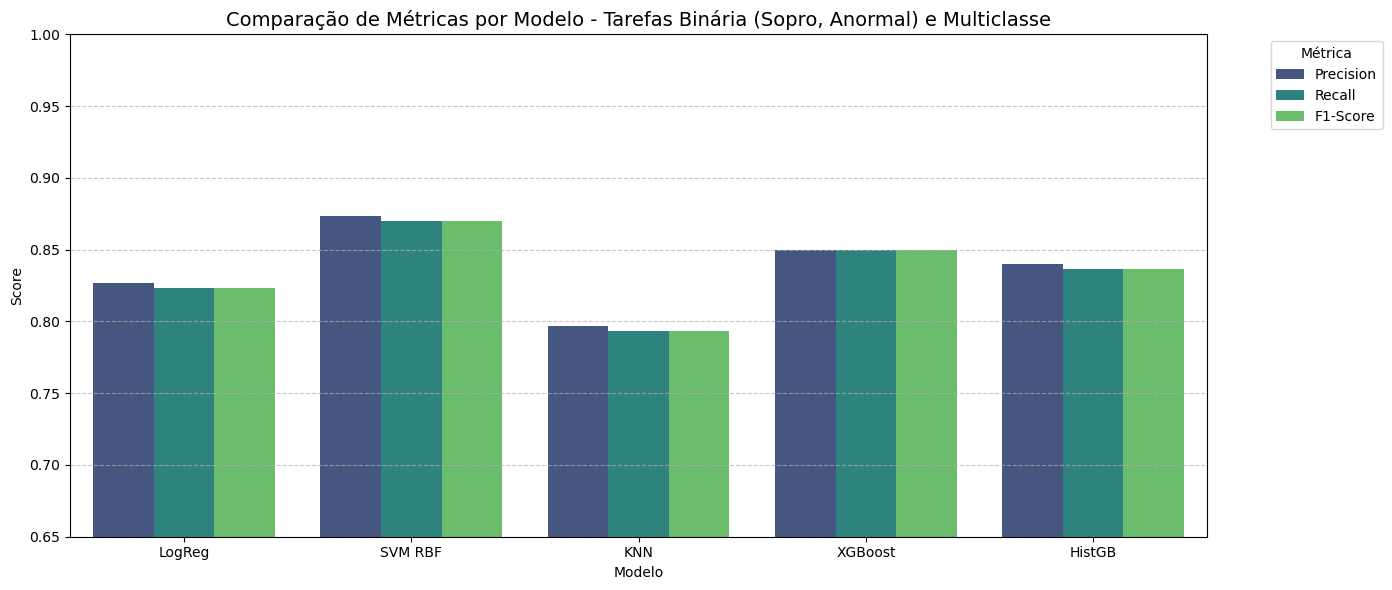

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


modelos = ['LogReg', 'SVM RBF', 'KNN', 'XGBoost', 'HistGB']

tarefa_binaria_sopro = {
    'LogReg': (0.97, 0.97, 0.97),
    'SVM RBF': (0.97, 0.97, 0.97),
    'KNN': (0.89, 0.89, 0.89),
    'XGBoost': (0.96, 0.96, 0.96),
    'HistGB': (0.97, 0.97, 0.97)
}

tarefa_binaria_anormal = {
    'LogReg': (0.76, 0.76, 0.76),
    'SVM RBF': (0.86, 0.86, 0.86),
    'KNN': (0.78, 0.78, 0.78),
    'XGBoost': (0.80, 0.80, 0.80),
    'HistGB': (0.75, 0.75, 0.75)
}

tarefa_multiclasse = {
    'LogReg': (0.75, 0.74, 0.74),
    'SVM RBF': (0.79, 0.78, 0.78),
    'KNN': (0.72, 0.71, 0.71),
    'XGBoost': (0.79, 0.79, 0.79),
    'HistGB': (0.80, 0.79, 0.79)
}

linhas = []
for tarefa, fonte in zip(
    ['Binária: Sopro', 'Binária: Anormal', 'Multiclasse'],
    [tarefa_binaria_sopro, tarefa_binaria_anormal, tarefa_multiclasse]
):
    for modelo in modelos:
        prec, rec, f1 = fonte[modelo]
        linhas.append({'Tarefa': tarefa, 'Modelo': modelo, 'Métrica': 'Precision', 'Valor': prec})
        linhas.append({'Tarefa': tarefa, 'Modelo': modelo, 'Métrica': 'Recall', 'Valor': rec})
        linhas.append({'Tarefa': tarefa, 'Modelo': modelo, 'Métrica': 'F1-Score', 'Valor': f1})

df_metricas = pd.DataFrame(linhas)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_metricas, x='Modelo', y='Valor', hue='Métrica', palette='viridis', ci=None)
plt.title('Comparação de Métricas por Modelo - Tarefas Binária (Sopro, Anormal) e Multiclasse', fontsize=14)
plt.ylim(0.65, 1.0)
plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Modelo')
plt.ylabel('Score')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Gráfico comparativo das métricas Precision, Recall e F1-Score para os cinco modelos (Logistic Regression, SVM RBF, KNN, XGBoost, HistGradientBoosting), considerando a média entre as três tarefas:

- Classificação binária: Normal vs. Sopro
- Classificação binária: Normal vs. Anormal
- Classificação multiclasse: 10 categorias

**Conclusões visuais**:

🔹 SVM RBF apresenta o melhor desempenho médio geral, com métricas próximas de 0.87

🔹 XGBoost também tem desempenho muito consistente, ligeiramente abaixo do SVM.

KNN foi o modelo mais fraco em média.

Todos os modelos reduziram o desempenho ao passar de tarefas binárias simples (Normal x Sopro) para tarefas mais complexas (Anormal e Multiclasse), o que é esperado e sinal de aprendizado real, não decoreba.